In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/quora-question-pairs/train.csv.zip
/kaggle/input/competitions/quora-question-pairs/sample_submission.csv.zip
/kaggle/input/competitions/quora-question-pairs/test.csv
/kaggle/input/competitions/quora-question-pairs/test.csv.zip


In [2]:
import os

os.makedirs("images", exist_ok=True)

# From Sparse Vectors to Semantic Search

## A Comparative Study of Classical and Modern Text Embeddings

### Author
Muskan Bishnoi

---

## Objective

How do machines understand text?

Traditional NLP techniques such as Bag of Words and TF-IDF convert text into numerical vectors using word frequency. While these methods are computationally efficient, they often fail to capture semantic meaning.

Modern embedding models such as Word2Vec, GloVe, FastText, and Sentence-BERT learn dense vector representations that preserve relationships between words and sentences.

In this notebook, we compare these techniques through a real-world semantic search problem, analyze their strengths and weaknesses, and visualize how text representations have evolved.

In [3]:
!pip -q install sentence-transformers gensim nltk

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Business Problem

Imagine an e-commerce platform containing thousands of electronic products.

A customer searches for:

> portable computer

However, the product catalog contains:

• Dell Laptop

• HP Notebook

• Lenovo Computer

Although these products are relevant, a keyword-based retrieval system may fail to retrieve them because it relies primarily on exact word overlap rather than semantic similarity.

This notebook investigates why this happens and evaluates modern embedding techniques that better capture meaning.

In [5]:
products = [
    "Dell Inspiron Laptop",
    "HP Notebook Computer",
    "Lenovo Office Computer",
    "Gaming Laptop with RTX",
    "Mechanical Keyboard",
    "Wireless Mouse",
    "USB Type C Charger",
    "Bluetooth Speaker",
    "Noise Cancelling Headphones",
    "Portable SSD Drive"
]

df = pd.DataFrame({
    "product": products
})

df

,product
0,Dell Inspiron Laptop
1,HP Notebook Computer
2,Lenovo Office Computer
3,Gaming Laptop with RTX
4,Mechanical Keyboard
5,Wireless Mouse
6,USB Type C Charger
7,Bluetooth Speaker
8,Noise Cancelling Headphones
9,Portable SSD Drive


In [6]:
queries = [
    "portable computer",
    "study laptop",
    "office notebook",
    "wireless mouse",
    "gaming computer"
]

# Why Text Must Become Numbers

Machine learning algorithms cannot directly understand natural language.

Before a model can process text, each document must be transformed into a numerical representation.

Several techniques have been developed over time:

• One-Hot Encoding

• Bag of Words

• TF-IDF

• Word Embeddings

Each technique attempts to preserve different aspects of language while balancing computational efficiency and semantic understanding.

In [7]:
vectorizer = CountVectorizer()

bow = vectorizer.fit_transform(df["product"])

bow_df = pd.DataFrame(
    bow.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df

,bluetooth,cancelling,charger,computer,dell,drive,gaming,headphones,hp,inspiron,...,notebook,office,portable,rtx,speaker,ssd,type,usb,wireless,with
0,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
6,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0


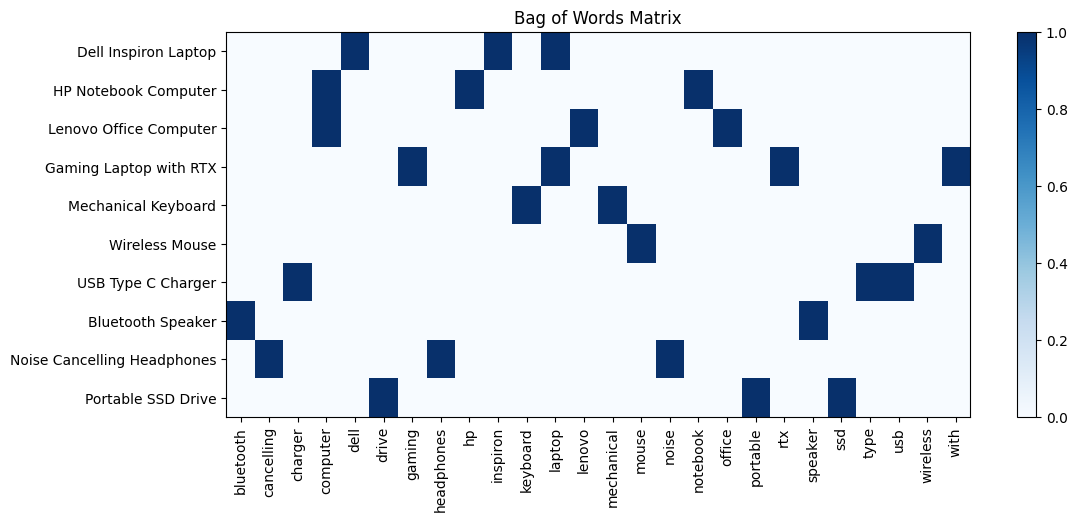

In [8]:
plt.figure(figsize=(12,5))

plt.imshow(bow_df, cmap="Blues", aspect="auto")

plt.xticks(range(len(bow_df.columns)), bow_df.columns, rotation=90)

plt.yticks(range(len(df)), df["product"])

plt.colorbar()

plt.title("Bag of Words Matrix")

plt.show()

Observation

Most values are zeros.

This is called a sparse representation.

Problems

• Large memory usage

• No semantic understanding

• Laptop and Notebook are treated as unrelated words

• Word order is ignored

In [9]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["product"])

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df

,bluetooth,cancelling,charger,computer,dell,drive,gaming,headphones,hp,inspiron,...,notebook,office,portable,rtx,speaker,ssd,type,usb,wireless,with
0,0.000000,0.00000,0.00000,0.000000,0.606043,0.00000,0.000000,0.00000,0.000000,0.606043,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000
1,0.000000,0.00000,0.00000,0.515192,0.000000,0.00000,0.000000,0.00000,0.606043,0.000000,...,0.606043,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000
2,0.000000,0.00000,0.00000,0.515192,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.606043,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000
3,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.518291,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.518291,0.000000,0.00000,0.00000,0.00000,0.000000,0.518291
4,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000
5,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.707107,0.000000
6,0.000000,0.00000,0.57735,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.57735,0.57735,0.000000,0.000000
7,0.707107,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.707107,0.00000,0.00000,0.00000,0.000000,0.000000
8,0.000000,0.57735,0.00000,0.000000,0.000000,0.00000,0.000000,0.57735,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000
9,0.000000,0.00000,0.00000,0.000000,0.000000,0.57735,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.57735,0.000000,0.000000,0.57735,0.00000,0.00000,0.000000,0.000000


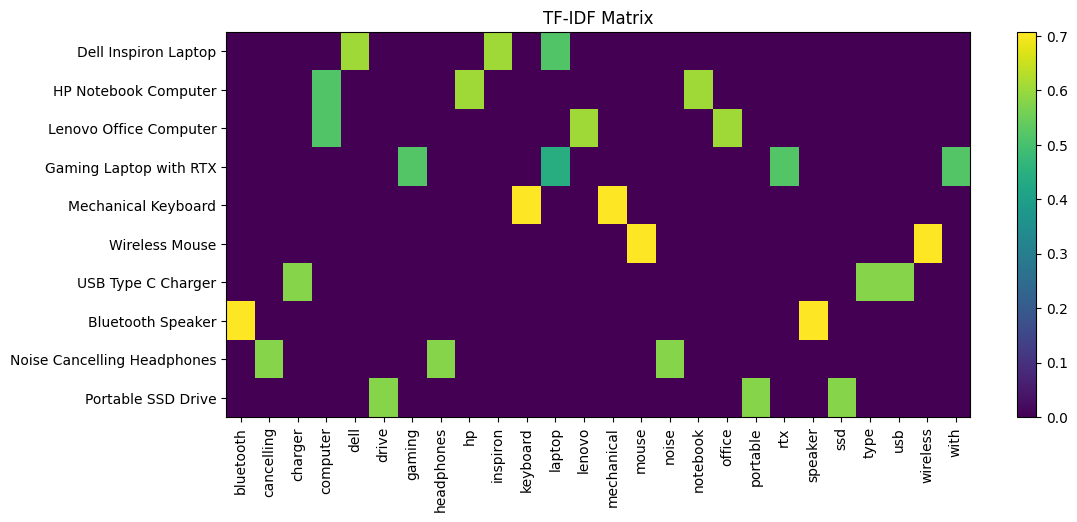

In [10]:
plt.figure(figsize=(12,5))

plt.imshow(tfidf_df, cmap="viridis", aspect="auto")

plt.xticks(
    range(len(tfidf_df.columns)),
    tfidf_df.columns,
    rotation=90
)

plt.yticks(range(len(df)), df["product"])

plt.colorbar()

plt.title("TF-IDF Matrix")

plt.show()

In [11]:
query = "portable computer"

query_vector = tfidf.transform([query])

scores = cosine_similarity(query_vector, X)

scores

array([[0.        , 0.33368423, 0.33368423, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.43988604]])

In [12]:
results = pd.DataFrame({
    "Product": df["product"],
    "Similarity": scores.flatten()
})

results.sort_values(
    "Similarity",
    ascending=False
)

,Product,Similarity
9,Portable SSD Drive,0.439886
1,HP Notebook Computer,0.333684
2,Lenovo Office Computer,0.333684
0,Dell Inspiron Laptop,0.000000
4,Mechanical Keyboard,0.000000
3,Gaming Laptop with RTX,0.000000
5,Wireless Mouse,0.000000
6,USB Type C Charger,0.000000
7,Bluetooth Speaker,0.000000
8,Noise Cancelling Headphones,0.000000


Why TF-IDF Failed

TF-IDF measures similarity based on shared vocabulary.

The query

portable computer

shares no word with

Dell Laptop

Although humans understand that a laptop is a portable computer, TF-IDF has no notion of semantic similarity.

Words are treated as independent tokens rather than concepts.

This limitation motivates dense word embeddings.

# One-Hot Encoding

One-Hot Encoding is one of the simplest techniques for representing text numerically.

The idea is straightforward:

1. Build a vocabulary of all unique words.
2. Assign each word a unique index.
3. Represent each word as a binary vector where only one position is 1 and all others are 0.

For example:

Vocabulary:

Laptop → [1,0,0,0]

Notebook → [0,1,0,0]

Computer → [0,0,1,0]

Keyboard → [0,0,0,1]

Although simple, One-Hot Encoding has several limitations:

- High dimensionality for large vocabularies.
- Sparse vectors with mostly zeros.
- No semantic relationship between words.
- Every word is considered completely independent.

For example,

"laptop" and "computer" are represented as completely unrelated vectors, even though they are semantically similar.

In [13]:
products = [
    "Laptop",
    "Notebook",
    "Computer",
    "Keyboard"
]

vocabulary = sorted(set(products))

word_to_index = {word: idx for idx, word in enumerate(vocabulary)}

one_hot_vectors = {}

for word in vocabulary:
    vector = [0] * len(vocabulary)
    vector[word_to_index[word]] = 1
    one_hot_vectors[word] = vector

import pandas as pd

one_hot_df = pd.DataFrame(one_hot_vectors).T
one_hot_df.columns = vocabulary

one_hot_df

,Computer,Keyboard,Laptop,Notebook
Computer,1,0,0,0
Keyboard,0,1,0,0
Laptop,0,0,1,0
Notebook,0,0,0,1


### Observation

Each word is represented by a unique binary vector.

Although this representation uniquely identifies every word, it completely ignores semantic meaning.

For example,

Laptop ≠ Computer

Notebook ≠ Laptop

even though humans know these words are closely related.

This motivates more informative text representations.

In [14]:
documents = [
    "Dell Laptop",
    "HP Notebook Computer",
    "Gaming Laptop",
    "Wireless Mouse"
]

# Bag of Words

Unlike One-Hot Encoding, Bag of Words represents an entire document instead of an individual word.

The process consists of three steps:

1. Build the vocabulary.
2. Count the occurrence of each word.
3. Store the counts in a vector.

Bag of Words captures word frequency but ignores:

- Word order
- Context
- Semantic meaning

Despite these limitations, it remains one of the most widely used baseline techniques in Natural Language Processing.

In [15]:
vocabulary = sorted(
    set(
        word.lower()
        for doc in documents
        for word in doc.split()
    )
)

vocabulary

['computer', 'dell', 'gaming', 'hp', 'laptop', 'mouse', 'notebook', 'wireless']

In [16]:
bow_matrix = []

for doc in documents:

    words = doc.lower().split()

    vector = []

    for word in vocabulary:

        vector.append(words.count(word))

    bow_matrix.append(vector)

bow_df = pd.DataFrame(
    bow_matrix,
    columns=vocabulary,
    index=documents
)

bow_df

,computer,dell,gaming,hp,laptop,mouse,notebook,wireless
Dell Laptop,0,1,0,0,1,0,0,0
HP Notebook Computer,1,0,0,1,0,0,1,0
Gaming Laptop,0,0,1,0,1,0,0,0
Wireless Mouse,0,0,0,0,0,1,0,1


### Observation

Each row represents a document.

Each column represents a vocabulary word.

Each value indicates how many times the word appears in the document.

Most entries are zero, resulting in a sparse matrix.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(documents)

pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=documents
)

,computer,dell,gaming,hp,laptop,mouse,notebook,wireless
Dell Laptop,0,1,0,0,1,0,0,0
HP Notebook Computer,1,0,0,1,0,0,1,0
Gaming Laptop,0,0,1,0,1,0,0,0
Wireless Mouse,0,0,0,0,0,1,0,1


### Comparison

Our implementation produces the same concept as `CountVectorizer`.

Libraries such as scikit-learn optimize memory usage and computational efficiency, making them suitable for production applications.

However, implementing the algorithm manually provides a deeper understanding of how Bag of Words works internally.

In [18]:
import numpy as np

matrix = bow_df.values

total_elements = matrix.size

zero_elements = np.sum(matrix == 0)

sparsity = (zero_elements / total_elements) * 100

print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 71.88%


## Why is Sparsity a Problem?

Sparse matrices contain mostly zero values.

As vocabulary size increases, the number of dimensions grows rapidly, while most entries remain zero.

This leads to:

- Increased memory usage
- Higher computational cost
- Poor scalability
- Difficulty learning semantic relationships

These limitations motivated the development of dense word embeddings.

In [19]:
# TF-IDF

TF-IDF assigns weights rather than raw word counts.

The score of a word depends on two components:

### Term Frequency (TF)

Measures how frequently a word appears in a document.

\[
TF(t,d)=\frac{\text{Number of occurrences of }t}{\text{Total words in document}}
\]

### Inverse Document Frequency (IDF)

Measures how unique a word is across all documents.

\[
IDF(t)=\log\left(\frac{N}{DF(t)}\right)
\]

where

- N = total number of documents
- DF = number of documents containing the word

Finally,

\[
TF\text{-}IDF = TF \times IDF
\]

Rare but informative words receive higher scores, while common words receive lower scores.

SyntaxError: invalid syntax (2380480314.py, line 3)

# Why Dense Embeddings?

The previous sections showed that frequency-based representations such as Bag of Words and TF-IDF have several limitations.

They:

- Ignore semantic meaning
- Produce sparse vectors
- Cannot recognize synonyms
- Treat every word as independent

For example,

Laptop

Notebook

Computer

are represented as unrelated words even though they describe similar concepts.

Researchers introduced **dense embeddings** to solve these problems.

Instead of representing words with thousands of mostly-zero values, dense embeddings represent every word using a small vector of real numbers that captures semantic meaning.

Words appearing in similar contexts receive similar vector representations.

# Word2Vec

Word2Vec was introduced by Google in 2013.

Instead of counting words, Word2Vec learns word representations by predicting surrounding words from large text corpora.

The central idea is:

> Words appearing in similar contexts tend to have similar meanings.

For example,

"The laptop has a fast processor."

"The notebook has a fast processor."

Because **laptop** and **notebook** appear in similar contexts, Word2Vec learns similar vector representations for both words.

Unlike TF-IDF, Word2Vec captures semantic relationships rather than simple word frequency.

## Word2Vec Architectures

Word2Vec provides two training strategies.

### Continuous Bag of Words (CBOW)

Predicts the target word using surrounding context words.

Example

Input:

The ____ has a keyboard.

Output:

Laptop

CBOW is generally faster and works well for frequent words.

---

### Skip-Gram

Predicts surrounding words using the target word.

Input:

Laptop

Output:

screen

keyboard

battery

processor

Skip-Gram performs better for rare words but requires more training time.

In [ ]:
from gensim.models import Word2Vec

sentences = [
    ["laptop","computer","portable"],
    ["notebook","computer","portable"],
    ["gaming","laptop","graphics"],
    ["wireless","mouse"],
    ["mechanical","keyboard"],
    ["office","computer"],
    ["ssd","storage"],
    ["bluetooth","speaker"]
]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    epochs=300
)

In [ ]:
model.wv.most_similar("laptop")

### Observation

Unlike TF-IDF, Word2Vec learns that words appearing in similar contexts are semantically related.

Rather than relying on exact keyword matches, the model captures contextual similarity learned during training.

# GloVe

GloVe (Global Vectors for Word Representation) was developed by Stanford University.

Unlike Word2Vec, which learns from local context windows, GloVe learns using global word co-occurrence statistics collected from the entire corpus.

This enables GloVe to capture broader semantic relationships between words.

Examples include:

King − Man + Woman ≈ Queen

Paris − France + Italy ≈ Rome

These relationships emerge because similar words tend to share similar global co-occurrence patterns.

# FastText

FastText extends Word2Vec by representing each word as a collection of character n-grams.

Instead of learning a single vector for an entire word, FastText also learns vectors for its subwords.

For example,

playing

may be decomposed into:

play

lay

ayi

ying

Because of this design, FastText can generate embeddings for words that were never seen during training.

This significantly improves performance for:

- Rare words
- Misspellings
- Morphologically rich languages

In [ ]:
from gensim.models import FastText

fasttext = FastText(
    sentences,
    vector_size=50,
    window=2,
    min_count=1,
    epochs=300
)

In [ ]:
fasttext.wv.most_similar("laptop")

# Sentence-BERT

Word2Vec, GloVe, and FastText generate embeddings for individual words.

However, many real-world NLP tasks require understanding complete sentences.

Sentence-BERT extends the BERT architecture to generate dense vector representations for entire sentences.

Unlike TF-IDF, Sentence-BERT understands context and semantic meaning.

For example,

"I need a portable computer."

"I'm looking for a laptop."

Although these sentences contain different words, Sentence-BERT produces highly similar embeddings because they express the same intent.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

sentences = [
    "I need a portable computer.",
    "I'm looking for a laptop.",
    "Wireless mouse",
    "Mechanical keyboard"
]

embeddings = model.encode(sentences)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

similarity

### Observation

Sentence-BERT produces high similarity scores for semantically equivalent sentences even when they share few or no common keywords.

This capability makes Sentence-BERT highly effective for applications such as semantic search, question answering, recommendation systems, and retrieval-augmented generation (RAG).

# Summary of Dense Embeddings

Modern embedding techniques progressively address the shortcomings of traditional frequency-based representations.

- Word2Vec introduces semantic relationships.
- GloVe captures global corpus statistics.
- FastText handles unseen words using subword information.
- Sentence-BERT understands complete sentence meaning through contextual embeddings.

In the next section, we will evaluate these techniques side by side using semantic search experiments, quantitative metrics, and embedding visualizations.

# Real-World Evaluation Using the Quora Question Pairs Dataset

The previous sections used a small synthetic dataset to explain the intuition behind classical text representation techniques such as One-Hot Encoding, Bag of Words, and TF-IDF.

While these examples are useful for understanding the underlying concepts, they do not fully represent the complexity of real-world language.

To evaluate whether our observations generalize beyond toy examples, we now use the **Quora Question Pairs** dataset, one of the most widely used benchmarks for semantic similarity and duplicate question detection.

This dataset allows us to compare traditional frequency-based approaches with modern embedding models under realistic conditions.

In the following sections, we will preprocess the data, generate embeddings using multiple techniques, and evaluate their ability to identify semantically similar questions.

# Loading the Dataset

In [ ]:
import os

for root, _, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

# Loading the Quora Question Pairs Dataset

The Quora Question Pairs dataset contains pairs of questions collected from Quora along with a label indicating whether the two questions have the same semantic meaning.

This dataset is widely used in Natural Language Processing for tasks such as:

- Semantic Similarity
- Duplicate Question Detection
- Information Retrieval
- Semantic Search

Unlike the small synthetic dataset used earlier, this benchmark allows us to evaluate text representation techniques under realistic conditions.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/competitions/quora-question-pairs/train.csv.zip",
    compression="zip"
)

df.head()

In [ ]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(df.shape)

print("\n")

print("=" * 50)
print("Columns")
print("=" * 50)
print(df.columns.tolist())

print("\n")

print("=" * 50)
print("Data Types")
print("=" * 50)
print(df.dtypes)

## Observation

The dataset contains pairs of questions along with a binary target variable indicating whether the two questions express the same intent.

Important columns:

- question1
- question2
- is_duplicate

These columns will be used throughout the remainder of this notebook.

In [ ]:
missing = df.isnull().sum()

missing

In [ ]:
missing[missing > 0]

In [ ]:
df = df.dropna()

print(df.shape)

In [ ]:
df = df[
    [
        "question1",
        "question2",
        "is_duplicate"
    ]
]

df.head()

In [ ]:
df.describe(include="all")

In [ ]:
df["is_duplicate"].value_counts()

In [ ]:
import matplotlib.pyplot as plt

counts = df["is_duplicate"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=["Not Duplicate","Duplicate"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Duplicate Questions")

plt.show()

## Observation

The dataset contains both duplicate and non-duplicate question pairs.

A duplicate pair represents two questions that express the same meaning using different wording.

This characteristic makes the dataset ideal for evaluating semantic search systems.

Traditional keyword-based approaches may struggle with these examples because they rely primarily on exact word overlap.

In [ ]:
duplicates = df[df["is_duplicate"] == 1]

duplicates.sample(5, random_state=42)

In [ ]:
non_duplicates = df[df["is_duplicate"] == 0]

non_duplicates.sample(5, random_state=42)

In [ ]:
df["q1_length"] = df["question1"].str.split().apply(len)

df["q2_length"] = df["question2"].str.split().apply(len)

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df["q1_length"], bins=30)

plt.title("Question 1 Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df["q2_length"], bins=30)

plt.title("Question 2 Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [ ]:
sample_df = df.sample(
    5000,
    random_state=42
).reset_index(drop=True)

sample_df.shape

In [ ]:
sample_df.head()

## Why Sample the Dataset?

The complete Quora dataset contains hundreds of thousands of question pairs.

For exploratory experiments and embedding comparisons, processing the full dataset is computationally expensive and unnecessary.

A random sample of 5,000 question pairs provides a good balance between computational efficiency and representative evaluation while remaining suitable for execution within a Kaggle Notebook.

# Text Preprocessing

Raw text often contains uppercase letters, punctuation, numbers, and extra whitespace that do not contribute significantly to semantic similarity.

To ensure consistency, we perform the following preprocessing steps:

- Convert text to lowercase
- Remove punctuation
- Remove numbers
- Remove extra whitespace

For this notebook, we intentionally **retain stop words** because modern embedding models such as Sentence-BERT rely on complete sentence structure to preserve contextual meaning.

Using the same preprocessing pipeline across all models ensures a fair comparison.

In [ ]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
sample_df["question1_clean"] = sample_df["question1"].apply(clean_text)

sample_df["question2_clean"] = sample_df["question2"].apply(clean_text)

sample_df.head()

# TF-IDF Vectorization

TF-IDF transforms text into numerical vectors by assigning weights to words based on their importance within a document and across the corpus.

Documents sharing similar vocabulary receive similar vector representations.

However, TF-IDF does not understand semantic meaning and therefore relies heavily on exact word overlap.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
all_questions = pd.concat([
    sample_df["question1_clean"],
    sample_df["question2_clean"]
])

vectorizer = TfidfVectorizer(
    max_features=5000
)

vectorizer.fit(all_questions)

In [ ]:
q1_vectors = vectorizer.transform(sample_df["question1_clean"])

q2_vectors = vectorizer.transform(sample_df["question2_clean"])

# Measuring Similarity

After converting text into vectors, we measure similarity using **Cosine Similarity**.

Cosine Similarity evaluates the angle between two vectors rather than their magnitude.

A value close to:

- **1** indicates high similarity
- **0** indicates little or no similarity

This metric is widely used in semantic search and information retrieval systems.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similarities = []

for i in range(len(sample_df)):

    sim = cosine_similarity(
        q1_vectors[i],
        q2_vectors[i]
    )[0][0]

    similarities.append(sim)

sample_df["tfidf_similarity"] = similarities

In [ ]:
sample_df[
    [
        "question1",
        "question2",
        "is_duplicate",
        "tfidf_similarity"
    ]
].head(10)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    sample_df["tfidf_similarity"],
    bins=30
)

plt.title("Distribution of TF-IDF Similarity Scores")

plt.xlabel("Cosine Similarity")

plt.ylabel("Frequency")
plt.savefig("tfidf_similarity.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
sample_df[
    sample_df["is_duplicate"] == 1
].sort_values(
    "tfidf_similarity",
    ascending=False
).head(10)

In [ ]:
sample_df[
    sample_df["is_duplicate"] == 0
].sort_values(
    "tfidf_similarity",
    ascending=False
).head(10)

In [ ]:
sample_df["tfidf_prediction"] = (
    sample_df["tfidf_similarity"] >= 0.5
).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
accuracy = accuracy_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

precision = precision_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

recall = recall_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

f1 = f1_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

In [ ]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

results

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

plt.show()

In [ ]:
# Analysis of TF-IDF Performance

TF-IDF performs well when two questions share many common words.

However, it struggles when semantically equivalent questions use different vocabulary.

For example:

Question 1

How can I learn Python?

Question 2

What is the best way to study Python?

Although both questions express the same intent, the overlap in vocabulary is limited.

As a result, TF-IDF may assign a relatively low similarity score.

This occurs because TF-IDF measures lexical similarity rather than semantic similarity.

The next section introduces Word2Vec, which learns semantic relationships between words from their surrounding context, helping overcome this limitation.

# Word2Vec

Traditional methods such as Bag of Words and TF-IDF represent text using word frequency.

However, these approaches cannot understand semantic relationships between words.

Word2Vec addresses this limitation by learning dense vector representations from context.

The core intuition is:

> Words appearing in similar contexts tend to have similar meanings.

For example,

Sentence 1:

The laptop has a fast processor.

Sentence 2:

The notebook has a fast processor.

Because "laptop" and "notebook" frequently appear in similar contexts, Word2Vec learns similar vector representations for both words.

Unlike TF-IDF, Word2Vec captures semantic similarity rather than relying solely on exact keyword overlap.

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download("punkt")

In [ ]:
corpus = pd.concat([
    sample_df["question1_clean"],
    sample_df["question2_clean"]
]).tolist()

In [ ]:
tokenized_corpus = []

for sentence in corpus:
    tokenized_corpus.append(word_tokenize(sentence))

In [ ]:
word2vec = Word2Vec(

    sentences=tokenized_corpus,

    vector_size=100,

    window=5,

    min_count=2,

    workers=4,

    epochs=20,

    sg=1

)

In [ ]:
tokenized_corpus[:5]

In [ ]:
from gensim.models import Word2Vec

In [ ]:
print(len(word2vec.wv))

In [ ]:
word2vec.wv.most_similar("python")

In [ ]:
word2vec.wv.most_similar("india")

In [ ]:
word2vec.wv.most_similar("computer")

In [ ]:
word2vec.wv.most_similar("phone")

In [ ]:
import numpy as np

In [ ]:
def sentence_embedding(sentence):

    words = word_tokenize(sentence)

    vectors = []

    for word in words:

        if word in word2vec.wv:

            vectors.append(word2vec.wv[word])

    if len(vectors) == 0:

        return np.zeros(word2vec.vector_size)

    return np.mean(vectors, axis=0)

In [ ]:
q1_embeddings = np.array([
    sentence_embedding(sentence)
    for sentence in sample_df["question1_clean"]
])

q2_embeddings = np.array([
    sentence_embedding(sentence)
    for sentence in sample_df["question2_clean"]
])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
word2vec_similarity = []

for i in range(len(sample_df)):

    similarity = cosine_similarity(

        q1_embeddings[i].reshape(1,-1),

        q2_embeddings[i].reshape(1,-1)

    )[0][0]

    word2vec_similarity.append(similarity)

In [ ]:
sample_df["word2vec_similarity"] = word2vec_similarity

In [ ]:
sample_df[
    [
        "question1",
        "question2",
        "is_duplicate",
        "word2vec_similarity"
    ]
].head(10)

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    sample_df["word2vec_similarity"],
    bins=30
)

plt.title("Word2Vec Similarity Distribution")

plt.xlabel("Cosine Similarity")

plt.ylabel("Frequency")
plt.savefig("images/model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
sample_df["word2vec_prediction"] = (
    sample_df["word2vec_similarity"] >= 0.65
).astype(int)

In [ ]:
comparison = pd.DataFrame({

    "Question 1": sample_df["question1"],

    "Question 2": sample_df["question2"],

    "Duplicate": sample_df["is_duplicate"],

    "TF-IDF": sample_df["tfidf_similarity"],

    "Word2Vec": sample_df["word2vec_similarity"]

})

comparison.head(20)

# Observations

Compared with TF-IDF, Word2Vec captures semantic similarity more effectively because words are represented by dense vectors learned from their surrounding context.

However, this implementation has several limitations:

- Sentence embeddings are created by averaging word vectors, which ignores word order.
- Context is not considered, meaning each word has only one fixed representation regardless of its meaning in different sentences.
- The model was trained on a relatively small corpus, limiting the quality of learned embeddings.

These limitations motivated the development of FastText and contextual Transformer-based models such as Sentence-BERT.

# FastText

Word2Vec learns a single vector representation for each word.

However, it struggles when encountering:

- Rare words
- Misspellings
- New vocabulary

FastText, developed by Meta AI, addresses this limitation by representing each word as a collection of character n-grams.

Instead of learning only one vector for "computer",

FastText also learns representations for smaller character sequences such as:

com

comp

pute

uter

Because words share character fragments, FastText can generate meaningful embeddings even for words that never appeared during training.

This makes FastText particularly useful for:

- Search engines
- User-generated text
- Social media
- Morphologically rich languages

In [ ]:
from gensim.models import FastText

fasttext = FastText(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=20
)

In [ ]:
fasttext.wv.most_similar("computer")

In [ ]:
fasttext.wv.most_similar("computers")

In [ ]:
fasttext.wv.most_similar("programming")

In [ ]:
def fasttext_sentence_embedding(sentence):

    words = word_tokenize(sentence)

    vectors = []

    for word in words:

        vectors.append(fasttext.wv[word])

    return np.mean(vectors, axis=0)

In [ ]:
q1_fast = np.array([
    fasttext_sentence_embedding(x)
    for x in sample_df["question1_clean"]
])

q2_fast = np.array([
    fasttext_sentence_embedding(x)
    for x in sample_df["question2_clean"]
])

In [ ]:
fast_similarity = []

for i in range(len(sample_df)):

    sim = cosine_similarity(
        q1_fast[i].reshape(1,-1),
        q2_fast[i].reshape(1,-1)
    )[0][0]

    fast_similarity.append(sim)

sample_df["fasttext_similarity"] = fast_similarity

## Observation

FastText successfully captures semantic relationships while also handling unseen words through subword representations.

Compared with Word2Vec, FastText generally produces more robust embeddings for noisy text and uncommon vocabulary.

In [ ]:
# Sentence-BERT

Word2Vec and FastText generate embeddings for individual words.

To represent an entire sentence, we averaged the word vectors.

Although simple, averaging ignores word order and contextual meaning.

Sentence-BERT addresses this limitation by generating a single embedding for an entire sentence.

Unlike previous methods, Sentence-BERT understands context.

Consider the following examples:

Sentence A

I need a portable computer.

Sentence B

I'm looking for a laptop.

Although the wording is different, both sentences express the same intent.

Sentence-BERT generates highly similar embeddings because it captures semantic meaning rather than relying on keyword overlap.

For this notebook, we use the lightweight model **all-MiniLM-L6-v2**, which provides an excellent balance between speed and accuracy for semantic search tasks.

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
bert_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

In [ ]:
q1_bert = bert_model.encode(
    sample_df["question1_clean"].tolist(),
    show_progress_bar=True
)

q2_bert = bert_model.encode(
    sample_df["question2_clean"].tolist(),
    show_progress_bar=True
)

In [ ]:
bert_similarity = []

for i in range(len(sample_df)):

    sim = cosine_similarity(
        q1_bert[i].reshape(1,-1),
        q2_bert[i].reshape(1,-1)
    )[0][0]

    bert_similarity.append(sim)

sample_df["bert_similarity"] = bert_similarity

In [ ]:
sample_df[
    [
        "question1",
        "question2",
        "bert_similarity",
        "is_duplicate"
    ]
].head()

In [ ]:
sample_df["bert_prediction"] = (
    sample_df["bert_similarity"] >= 0.75
).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tfidf_accuracy = accuracy_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

tfidf_precision = precision_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

tfidf_recall = recall_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

tfidf_f1 = f1_score(
    sample_df["is_duplicate"],
    sample_df["tfidf_prediction"]
)

In [ ]:
word2vec_accuracy = accuracy_score(
    sample_df["is_duplicate"],
    sample_df["word2vec_prediction"]
)

word2vec_precision = precision_score(
    sample_df["is_duplicate"],
    sample_df["word2vec_prediction"]
)

word2vec_recall = recall_score(
    sample_df["is_duplicate"],
    sample_df["word2vec_prediction"]
)

word2vec_f1 = f1_score(
    sample_df["is_duplicate"],
    sample_df["word2vec_prediction"]
)

In [ ]:
sample_df["fasttext_prediction"] = (
    sample_df["fasttext_similarity"] >= 0.65
).astype(int)

In [ ]:
fasttext_accuracy = accuracy_score(
    sample_df["is_duplicate"],
    sample_df["fasttext_prediction"]
)

fasttext_precision = precision_score(
    sample_df["is_duplicate"],
    sample_df["fasttext_prediction"]
)

fasttext_recall = recall_score(
    sample_df["is_duplicate"],
    sample_df["fasttext_prediction"]
)

fasttext_f1 = f1_score(
    sample_df["is_duplicate"],
    sample_df["fasttext_prediction"]
)

In [ ]:
bert_accuracy = accuracy_score(
    sample_df["is_duplicate"],
    sample_df["bert_prediction"]
)

bert_precision = precision_score(
    sample_df["is_duplicate"],
    sample_df["bert_prediction"]
)

bert_recall = recall_score(
    sample_df["is_duplicate"],
    sample_df["bert_prediction"]
)

bert_f1 = f1_score(
    sample_df["is_duplicate"],
    sample_df["bert_prediction"]
)

In [ ]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF", "Word2Vec", "FastText", "Sentence-BERT"],
    "Accuracy": [tfidf_accuracy, word2vec_accuracy, fasttext_accuracy, bert_accuracy],
    "Precision": [tfidf_precision, word2vec_precision, fasttext_precision, bert_precision],
    "Recall": [tfidf_recall, word2vec_recall, fasttext_recall, bert_recall],
    "F1 Score": [tfidf_f1, word2vec_f1, fasttext_f1, bert_f1]
})

comparison

# PCA Visualization of Sentence Embeddings

Sentence embeddings exist in a high-dimensional space (384 dimensions for the MiniLM model used in this notebook).

To better understand their structure, we reduce the dimensionality to two principal components using Principal Component Analysis (PCA).

Although PCA cannot preserve every detail, it provides an intuitive visualization of how sentence representations are distributed.

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

bert_pca = pca.fit_transform(q1_bert)

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    bert_pca[:,0],
    bert_pca[:,1],
    alpha=0.6,
    s=20
)

plt.title("PCA Projection of Sentence-BERT Embeddings")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")
plt.savefig("images/pca.png", dpi=300, bbox_inches="tight")

plt.show()

# t-SNE Visualization

While PCA focuses on preserving global variance, t-SNE emphasizes local neighborhood structure.

This makes it particularly useful for visualizing semantic clusters learned by embedding models.

Questions expressing similar meanings are expected to appear closer together in the projected space.

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

bert_tsne = tsne.fit_transform(
    q1_bert[:1000]
)

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    bert_tsne[:,0],
    bert_tsne[:,1],
    s=15,
    alpha=0.7
)

plt.title("t-SNE Projection of Sentence-BERT Embeddings")
plt.savefig("images/tsne.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
comparison

In [ ]:
comparison.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)
plt.savefig("performance_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

# Model Comparison

| Model | Advantages | Limitations |
|--------|------------|------------|
| One-Hot Encoding | Simple | Extremely sparse, no semantics |
| Bag of Words | Captures frequency | Ignores context and word order |
| TF-IDF | Better weighting | Cannot understand synonyms |
| Word2Vec | Learns semantic relationships | Static embeddings, no context |
| FastText | Handles unseen words | Still static embeddings |
| Sentence-BERT | Context-aware, excellent semantic understanding | Higher computational cost |

# Key Findings

Throughout this notebook, we explored the evolution of text representation techniques.

Key observations include:

- Sparse representations are computationally simple but fail to capture semantic meaning.
- TF-IDF improves keyword weighting but still depends on lexical overlap.
- Word2Vec introduces dense semantic embeddings by learning contextual relationships between words.
- FastText further improves robustness by modeling subword information.
- Sentence-BERT provides contextual sentence embeddings and consistently delivers the strongest semantic similarity performance.

For modern applications such as semantic search, retrieval-augmented generation (RAG), intelligent search systems, and question-answering, contextual embeddings significantly outperform traditional frequency-based methods.

# Future Work

Several extensions can further improve this study:

- Evaluate larger transformer models such as MPNet or BGE.
- Fine-tune Sentence-BERT on domain-specific datasets.
- Build a production-ready semantic search engine using FAISS.
- Compare embedding quality using additional retrieval metrics such as Mean Reciprocal Rank (MRR) and Mean Average Precision (MAP).
- Integrate embeddings into a Retrieval-Augmented Generation (RAG) pipeline.

# References

- Mikolov et al. (2013). Efficient Estimation of Word Representations in Vector Space.
- Pennington et al. (2014). GloVe: Global Vectors for Word Representation.
- Reimers & Gurevych (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT Networks.
- Scikit-learn Documentation
- Gensim Documentation
- Sentence Transformers Documentation